# Digital Health and Human behavior

## Requirements

In [112]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os


# Preprocessing from (https://github.com/ojwalch/sleep_classifiers) and modified to get other features
from sleep_classifiers.source.preprocessing.preprocessing_runner import run_preprocessing

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from matplotlib.colors import LinearSegmentedColormap

from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import shap

from scipy.stats import f_oneway, zscore
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

## Get Data and Preprocessing

### Important PATHS

In [2]:
PATH = os.getcwd()
DATA_PATH = os.path.join(PATH, 'sleep_classifiers', 'outputs')
RAW_DATA_PATH = os.path.join(PATH, 'sleep_classifiers', 'data')

### RAW DATA

In [3]:
HEART_RATE_PATH = os.path.join(RAW_DATA_PATH, 'heart_rate')
LABELS_PATH = os.path.join(RAW_DATA_PATH, 'labels')
MOTION_PATH = os.path.join(RAW_DATA_PATH, 'motion')
STEPS_PATH = os.path.join(RAW_DATA_PATH, 'steps')
data_values = {HEART_RATE_PATH: ['timestamp', 'heart_rate'], 
               LABELS_PATH: ['timestamp', 'label'],
               MOTION_PATH: ['timestamp', 'x', 'y', 'z'], 
               STEPS_PATH: ['timestamp', 'steps']}

In [4]:
# Get all IDs
subject_ids = sorted([file.split('_')[0] for file in os.listdir(HEART_RATE_PATH)])

In [5]:
# read the raw data into pandas dataframe and keep them in dictionaries
data_by_dir = {}
for path, columns_names in data_values.items():
    dir_name = os.path.basename(path.rstrip(os.sep))
    if dir_name == 'labels':
        data_by_dir[dir_name] = {
            fname: pd.read_csv(os.path.join(path, str(fname)+'_labeled_sleep.txt'), sep=" ", header=None, names=columns_names).drop_duplicates()
            for fname in subject_ids
        }
    elif dir_name == 'motion':
        data_by_dir[dir_name] = {
            fname: pd.read_csv(os.path.join(path, str(fname)+'_acceleration.txt'), sep=" ", header=None, names=columns_names).drop_duplicates()
            for fname in subject_ids
        }
    elif dir_name == 'heart_rate':
        data_by_dir[dir_name] = {
            fname: pd.read_csv(os.path.join(path, str(fname)+'_heartrate.txt'), sep=",", header=None, names=columns_names).drop_duplicates()
            for fname in subject_ids
        }
    else: 
        data_by_dir[dir_name] = {
            fname: pd.read_csv(os.path.join(path, str(fname)+'_steps.txt'), sep=",", header=None, names=columns_names).drop_duplicates()
            for fname in subject_ids
        }

### Preprocessing

In [6]:
run_preprocessing(subject_ids)

Cropping data from subject 1066528...
Cropping data from subject 1360686...
Cropping data from subject 1449548...
Cropping data from subject 1455390...
Cropping data from subject 1818471...
Cropping data from subject 2598705...
Cropping data from subject 2638030...
Cropping data from subject 3509524...
Cropping data from subject 3997827...
Cropping data from subject 4018081...
Cropping data from subject 4314139...
Cropping data from subject 4426783...
Cropping data from subject 46343...
Cropping data from subject 5132496...
Cropping data from subject 5383425...
Cropping data from subject 5498603...
Cropping data from subject 5797046...
Cropping data from subject 6220552...
Cropping data from subject 759667...
Cropping data from subject 7749105...
Cropping data from subject 781756...
Cropping data from subject 8000685...
Cropping data from subject 8173033...
Cropping data from subject 8258170...
Cropping data from subject 844359...
Cropping data from subject 8530312...
Cropping data fro

#### Preprocessed Data

In [7]:
# Read the preprocessed data from the last cell
data_by_subject = {}
for file in os.listdir(os.path.join(DATA_PATH, 'features')):
    subject_id = file.split('_')[0]
    filename = file.split('_')
    column = filename[1]
    if len(filename) > 3:
        column = '_'.join(filename[1:])
    df = pd.read_csv(os.path.join(DATA_PATH, 'features', file), header=None, names=[column])
    if subject_id in data_by_subject:
        data_by_subject[subject_id] = pd.concat([data_by_subject[subject_id], df], axis=1)
    else:
        data_by_subject[subject_id] = df

#### Advance Preprocessing and Feature Engineering

##### Motion Magnitude Dataset

In [8]:
def motion_to_cosine_features(x, y, z):
    """
    Convert 3D motion vectors to cosine-based features
    
    Returns:
    - magnitude: sqrt(x^2 + y^2 + z^2) - strength of motion
    - cosine_xy: cos(atan2(y, x)) - phase angle in xy plane
    - cosine_xz: cos(atan2(z, x)) - phase angle in xz plane
    """
    magnitude = np.sqrt(x**2 + y**2 + z**2)
    
    angle_xy = np.arctan2(y, x)
    angle_xz = np.arctan2(z, x)
    
    cosine_xy = np.cos(angle_xy)
    cosine_xz = np.cos(angle_xz)
    
    return magnitude, cosine_xy, cosine_xz


Convert the x, y, z acceleration to a magnitude of type $\sqrt{x^2 + y^2 + z^2}$ and also getting some other variables cosine_xy and cosine_xz that are obtained by cosine_xy = $\cos{(\arctan\left( \frac{y}{x} \right))}$ and cosine_xz = $\cos{(\arctan\left( \frac{z}{x} \right))}$


In [9]:
motion_magnitude = {}
CROPPED_PATH = os.path.join(DATA_PATH, 'cropped')
for subject_id in subject_ids:
    MOTION_FILE_PATH = os.path.join(CROPPED_PATH, f"{subject_id}_cleaned_motion.out")
    cropped_df = pd.read_csv(MOTION_FILE_PATH, sep=" ", header=None, names=['timestamp', 'x', 'y', 'z'])
    mag, cos_xy, cos_xz = motion_to_cosine_features(cropped_df['x'], cropped_df['y'], cropped_df['z'])
    df_features = pd.DataFrame({
            'timestamp': cropped_df['timestamp'].values/60/60,
            'magnitude': mag,
            'cosine_xy': cos_xy,
            'cosine_xz': cos_xz,
            'x':cropped_df['x'].values,
            'y':cropped_df['y'].values,
            'z':cropped_df['z'].values
        })
    time_feature_path = os.path.join(DATA_PATH,'features' ,f"{subject_id}_time_feature.out")
    if os.path.exists(time_feature_path):
        target_times_hours = pd.read_csv(time_feature_path, header=None, names=['time']).values.flatten()
        
        # Interpolate magnitude and cosine features to target times
        magnitude_interp = np.interp(target_times_hours, df_features['timestamp'].values, df_features['magnitude'].values)
        cosine_xy_interp = np.interp(target_times_hours, df_features['timestamp'].values, df_features['cosine_xy'].values)
        cosine_xz_interp = np.interp(target_times_hours, df_features['timestamp'].values, df_features['cosine_xz'].values)
        x_interp = np.interp(target_times_hours, df_features['timestamp'].values, df_features['x'].values)
        y_interp = np.interp(target_times_hours, df_features['timestamp'].values, df_features['y'].values)
        z_interp = np.interp(target_times_hours, df_features['timestamp'].values, df_features['z'].values)

        motion_magnitude[subject_id] = pd.DataFrame({
            'time_hours': target_times_hours,
            'magnitude': magnitude_interp,
            'cosine_xy': cosine_xy_interp,
            'cosine_xz': cosine_xz_interp,
            'x': x_interp,
            'y': y_interp,
            'z': z_interp
        })

In [10]:
# Feature Engineering:
# Create a two variables that contains the mean and the standard deviation of the magnitude over 5 minutes
# 5 minutes = 300 seconds, with 30-second epochs = 10 epochs

window_size_5min = 10

for id in subject_ids:
    if id in motion_magnitude:
        df = motion_magnitude[id].copy()
        
        # Compute rolling standard deviation
        df['magnitude_std_5min'] = df['magnitude'].rolling(
            window=window_size_5min, 
            center=True, 
            min_periods=1).std()
        # Compute rolling standard deviation
        df['magnitude_mean_5min'] = df['magnitude'].rolling(
            window=window_size_5min, 
            center=True, 
            min_periods=1).mean()
        
        motion_magnitude[id]['magnitude_std_5min'] = df['magnitude_std_5min']
        motion_magnitude[id]['magnitude_mean_5min'] = df['magnitude_mean_5min']

##### Steps Dataset

In [ ]:
# Preprocess steps dataset
# 1. Get only steps made before PSG start
# 2. Convert the timestamps from seconds to days.

steps_data = {}
for id in subject_ids:
    steps_data[id] = data_by_dir['steps'][id][(data_by_dir['steps'][id]['timestamp'] <= 0)]
    steps_data[id]['timestamp'] = - steps_data[id]['timestamp'] / 3600/24 

In [12]:
# Feature Engineering:
# 1. Create Steps per day 
# 2. Create Mean Steps Per Day
# 3. Create Physical Activity: Sedentary (<5000 steps); Low Active(5000~7500); Somewhat Active(7500~10000); 
#                              Active(10000~12500); Highly Active(>12500)


for id in subject_ids:
    days = max(steps_data[id]['timestamp'].astype(int))+1
    steps_data[id]['steps_per_day'] = 0
    for day in range(days):
        steps_data[id]['steps_per_day'][steps_data[id]['timestamp'].astype(int) == day] = steps_data[id]['steps'][steps_data[id]['timestamp'].astype(int) == day].sum()
        steps_data[id]['mean_steps_per_day'] = steps_data[id]['steps_per_day'].mean()
        if (steps_data[id]['mean_steps_per_day'] < 5000).all():
            steps_data[id]['physical_activity'] = 'sedentary'
        elif (5000 <= steps_data[id]['mean_steps_per_day']).all() & (steps_data[id]['mean_steps_per_day'] < 7500).all():
            steps_data[id]['physical_activity'] = 'low active'
        elif (7500 <= steps_data[id]['mean_steps_per_day']).all() & (steps_data[id]['mean_steps_per_day'] < 10000).all():
            steps_data[id]['physical_activity'] = 'somewhat active'
        elif (10000 <= steps_data[id]['mean_steps_per_day']).all() & (steps_data[id]['mean_steps_per_day'] < 12500).all():
            steps_data[id]['physical_activity'] = 'active'
        elif (steps_data[id]['mean_steps_per_day'] >= 12500).all():
            steps_data[id]['physical_activity'] = 'highly active'

### Merge all datasets

In [13]:
# Merge Preprocessed dataset with motion Magnitude Dataset
for id in subject_ids:
    data_by_subject[id] = pd.merge(data_by_subject[id], motion_magnitude[id], 
                                   left_index=True, right_index=True)

In [14]:
rename_columns = {
    'magnitude': 'motion_magnitude',
    'hr_feature_norm.out': 'heart_rate_std',
    'hr': 'heart_rate_mean',
    'psg': 'sleep_label',
    'count': 'activity_count'
}

In [15]:
# Rename some variables to understand them better
for id in subject_ids:
    data_by_subject[id].rename(columns=rename_columns, inplace=True)
    data_by_subject[id].drop(columns=['time_hours'], inplace=True)

In [16]:
data_by_subject[id]

,cosine,activity_count,heart_rate_mean,heart_rate_std,sleep_label,time,motion_magnitude,cosine_xy,cosine_xz,x,y,z,magnitude_std_5min,magnitude_mean_5min
0,-0.258819,6.390680,51.550296,0.415926,0.0,0.000000,0.993939,-0.749278,-0.294335,-0.283127,0.250244,-0.919311,0.005291,0.996730
1,-0.260926,5.588678,51.283967,0.399935,0.0,0.008333,0.993773,-0.747729,-0.338121,-0.321822,0.285786,-0.895735,0.005005,0.996065
2,-0.263031,6.464726,51.181156,0.388669,0.0,0.016667,0.998107,-0.748128,-0.345213,-0.329458,0.292213,-0.895703,0.004580,0.995945
3,-0.265135,8.771043,51.463285,0.376064,0.0,0.025000,1.005396,-0.455426,-0.401502,-0.317509,-0.620676,-0.724353,0.004261,0.995796
4,-0.267238,12.421686,51.703421,0.374685,0.0,0.033333,0.992435,-0.921667,-0.301531,-0.296868,-0.124963,-0.938711,0.004618,0.995019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
706,-0.969766,39.468501,75.290990,1.354802,0.0,5.941667,1.021853,-0.175635,-0.451411,-0.168485,0.950248,-0.335506,0.010161,0.994417
707,-0.969231,45.301776,76.027359,1.305644,0.0,5.950000,0.986966,-0.959643,-0.386751,-0.379288,0.111145,-0.904368,0.010628,0.994949
708,-0.968692,49.130978,77.808384,1.256228,0.0,5.958333,0.992975,-0.999801,-0.391906,-0.389141,-0.007729,-0.913514,0.011325,0.995237
709,-0.968148,50.419182,78.830902,1.257572,0.0,5.966667,0.995046,-0.710319,-0.269376,-0.258972,0.256633,-0.925841,0.011419,0.996673


In [17]:
# Combine all subjects by making a concatenation of the datasets of each subject
data_subjects= pd.DataFrame()
for id, data in data_by_subject.items():
    data_copy = data.copy()
    data_copy['id'] = id
    data_subjects = pd.concat([data_subjects, data_copy])

Transform Steps Table

In [18]:
# Trensforming the Steps Dataset into the following type
steps_final = pd.DataFrame()
for id in subject_ids: 
    steps_copy = steps_data[id].copy()
    steps_copy['day'] = steps_copy['timestamp'].astype(int)
    steps_copy.drop(columns=['timestamp', 'steps'], inplace=True)
    pivoted = steps_copy[['steps_per_day', 'day']].pivot_table(columns='day', values='steps_per_day', aggfunc='first').reset_index(drop=True)
    pivoted['mean_steps_per_day'] = steps_copy['mean_steps_per_day'].iloc[0]
    pivoted['physical_activity'] = steps_copy['physical_activity'].iloc[0]
    pivoted['id'] = id
    steps_final = pd.concat([steps_final, pivoted], ignore_index=True, axis=0)

steps_final.columns.name = None

In [19]:
steps_final.head()

,1,2,3,4,mean_steps_per_day,physical_activity,id,0,5,6
0,1708,3604,11349,2714.0,5976.327456,low active,1066528,NaN,NaN,NaN
1,9032,3668,7329,2125.0,8978.571429,somewhat active,1360686,6376.0,19132.0,15188.0
2,3083,9862,6992,13071.0,8453.285714,somewhat active,1449548,2600.0,17501.0,6064.0
3,10608,10729,13561,6344.0,14758.571429,highly active,1455390,11094.0,31478.0,19496.0
4,5442,6623,11753,7329.0,6530.285714,low active,1818471,6844.0,1662.0,6059.0


Merge with Transformed Steps Table

In [20]:
# Merge the new steps dataset with the dataset where all subjects where combined
final_merge = pd.merge(data_subjects, steps_final, on='id', how='left')

In [21]:
# Convert into One-Hot the qualitative variable 
df_dummies = pd.get_dummies(final_merge, columns=['physical_activity'], drop_first=True)

In [22]:
# Drop the ID column as it is not needed for the model
df_dummies.drop(columns=['id'], inplace=True)

In [23]:
# Ensure all columns are of type string
df_dummies.columns = df_dummies.columns.astype(str)

### Impute missing values

In [80]:
print('Variable missing percentage')
df_dummies.isna().sum()/df_dummies.shape[0]

Variable missing percentage


cosine                               0.000000
activity_count                       0.000000
heart_rate_mean                      0.000000
heart_rate_std                       0.000000
sleep_label                          0.000000
time                                 0.000000
motion_magnitude                     0.000000
cosine_xy                            0.000000
cosine_xz                            0.000000
x                                    0.000000
y                                    0.000000
z                                    0.000000
magnitude_std_5min                   0.000000
magnitude_mean_5min                  0.000000
1                                    0.000000
2                                    0.000000
3                                    0.000000
4                                    0.038068
mean_steps_per_day                   0.000000
0                                    0.070131
5                                    0.107139
6                                 

In [73]:
print('Overall percentage missing', (df_dummies.isna().sum()/df_dummies.shape[0]).sum()/df_dummies.shape[1])

Overall percentage missing 0.015353823210657714


In [24]:
# Impute missing values using KNN Imputer
#
imputer = KNNImputer(n_neighbors=5)
df_imputed = imputer.fit_transform(df_dummies)
df_imputed = pd.DataFrame(df_imputed, columns=df_dummies.columns)

### Outliers

Detecting Outliers by ploting the data into a PCA. The using z-score to delete those outliers

In [25]:
# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_imputed)

In [26]:
# Apply PCA
#
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

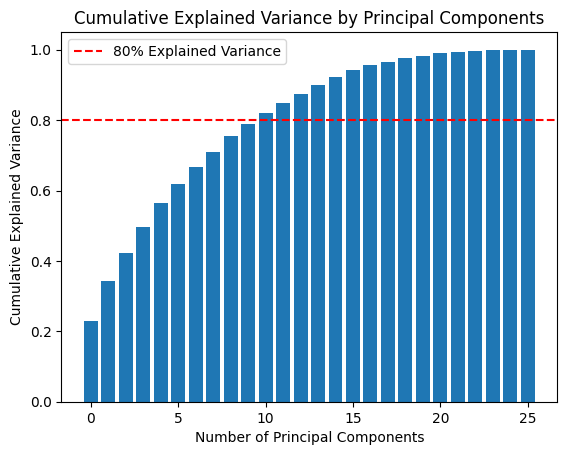

In [90]:
# Plot the cumulative explained variance of each principal component
#
cumulative_explained_variance = np.cumsum(pca.explained_variance_ratio_)
plt.bar(range(len(cumulative_explained_variance)), cumulative_explained_variance)
plt.axhline(y=0.8, color='r', linestyle='--', label='80% Explained Variance')
plt.ylabel('Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.title('Cumulative Explained Variance by Principal Components')
plt.legend()
plt.show()

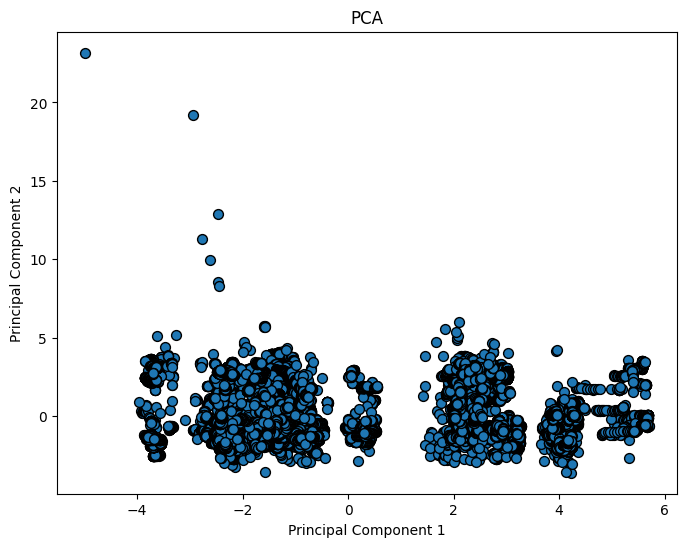

In [28]:
# Plot the first two principal components
#
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], edgecolor='k', s=50)
plt.title('PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

In [102]:
# Detect outliers based on z-scores in the PCA-transformed space
# And remove them from the original dataset
#
z_scores_pc = np.abs(zscore(X_pca[:, :11]))
threshold = 3
outliers = np.where(z_scores_pc > threshold)
df_cleaned = np.delete(df_imputed, outliers[0], axis=0)

In [109]:
# Convert back to DataFrame
#
df_cleaned = pd.DataFrame(df_cleaned, columns = df_imputed.columns)

## Data Visualization

### Subject Level visualization

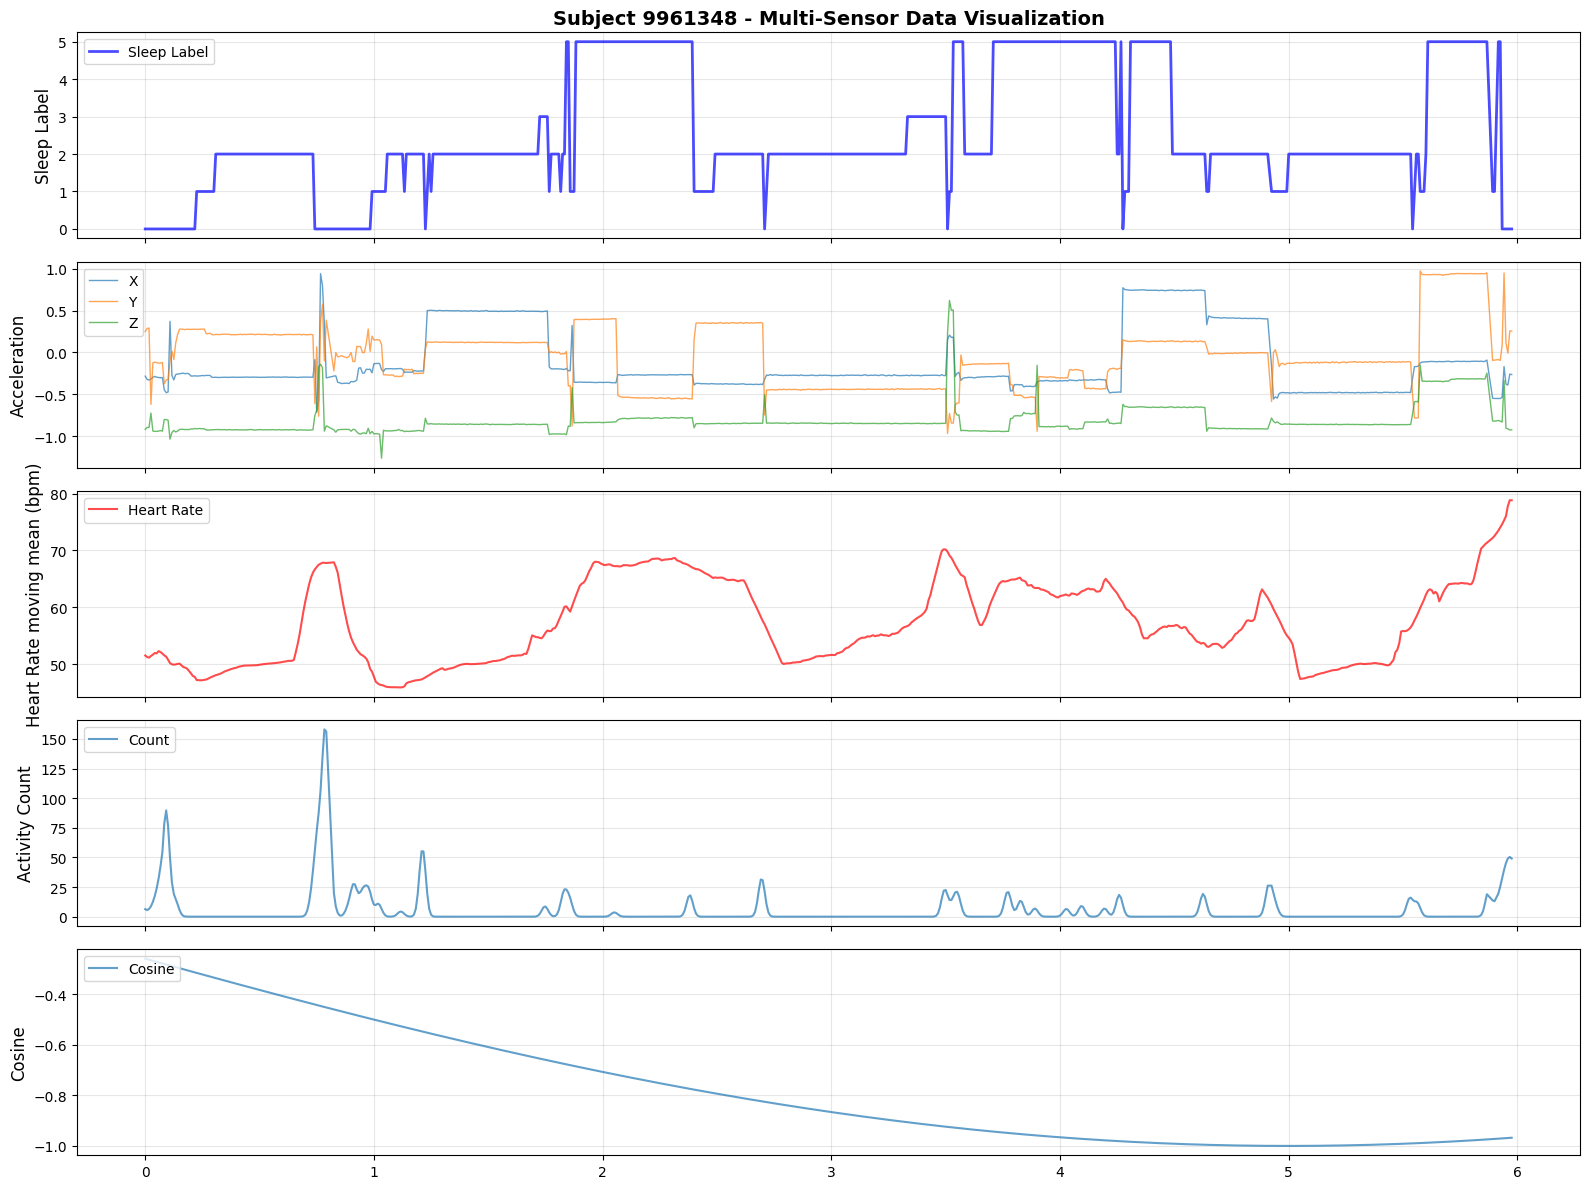

In [104]:
subject= '9961348'
accel_data = motion_magnitude[subject]
data = data_by_subject[subject]

fig, axes = plt.subplots(5, 1, figsize=(16, 12), sharex=True)

# Sleep Labels
ax1 = axes[0]
ax1.plot(data['time'], data['sleep_label'], label='Sleep Label', alpha=0.7, color='blue', linewidth=2)
ax1.set_ylabel('Sleep Label', fontsize=12)
ax1.set_title(f'Subject {subject} - Multi-Sensor Data Visualization', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left')

# Acceleration (X, Y, Z)
ax2 = axes[1]
ax2.plot(accel_data['time_hours'], accel_data['x'], label='X', alpha=0.7, linewidth=1)
ax2.plot(accel_data['time_hours'], accel_data['y'], label='Y', alpha=0.7, linewidth=1)
ax2.plot(accel_data['time_hours'], accel_data['z'], label='Z', alpha=0.7, linewidth=1)
ax2.set_ylabel('Acceleration', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper left')

# Heart Rate
ax3 = axes[2]
ax3.plot(data['time'], data['heart_rate_mean'], label='Heart Rate', alpha=0.7, color='red', linewidth=1.5)
ax3.set_ylabel('Heart Rate moving mean (bpm)', fontsize=12)
ax3.grid(True, alpha=0.3)
ax3.legend(loc='upper left')

# Activity Count
ax4 = axes[3]
ax4.plot(data['time'], data['activity_count'], label='Count', alpha=0.7, linewidth=1.5)
ax4.set_ylabel('Activity Count', fontsize=12)
ax4.grid(True, alpha=0.3)
ax4.legend(loc='upper left')

# Cosine Feature
ax5 = axes[4]
ax5.plot(data['time'], data['cosine'], label='Cosine', alpha=0.7, linewidth=1.5)
ax5.set_ylabel('Cosine', fontsize=12)
ax5.grid(True, alpha=0.3)
ax5.legend(loc='upper left')
plt.tight_layout()
plt.show()

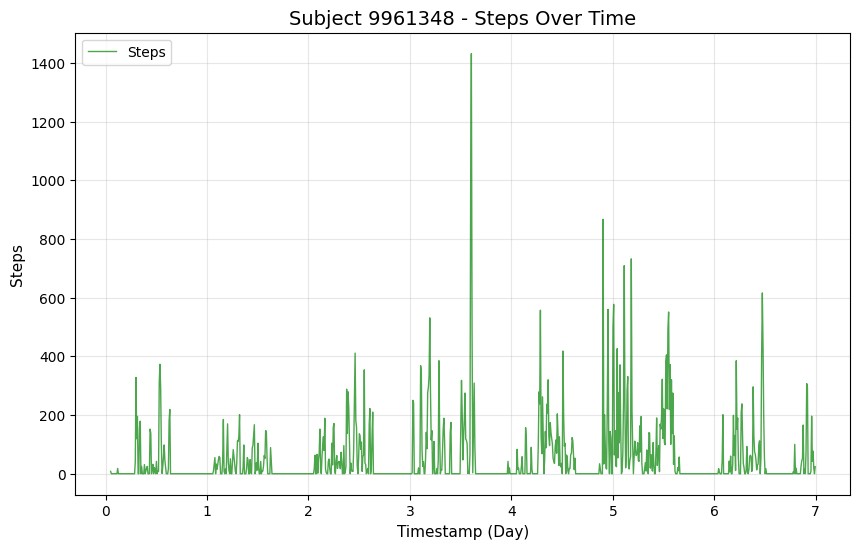

In [105]:
# Steps 

plt.figure(figsize=(10, 6)) 
plt.plot(steps_data[subject]['timestamp'], steps_data[subject]['steps'], label='Steps', alpha=0.7, color='green', linewidth=1)
plt.title(f'Subject {subject} - Steps Over Time', fontsize=14)
plt.xlabel('Timestamp (Day)', fontsize=11)
plt.ylabel('Steps', fontsize=11)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left')
plt.show()

### Group Level Visualization

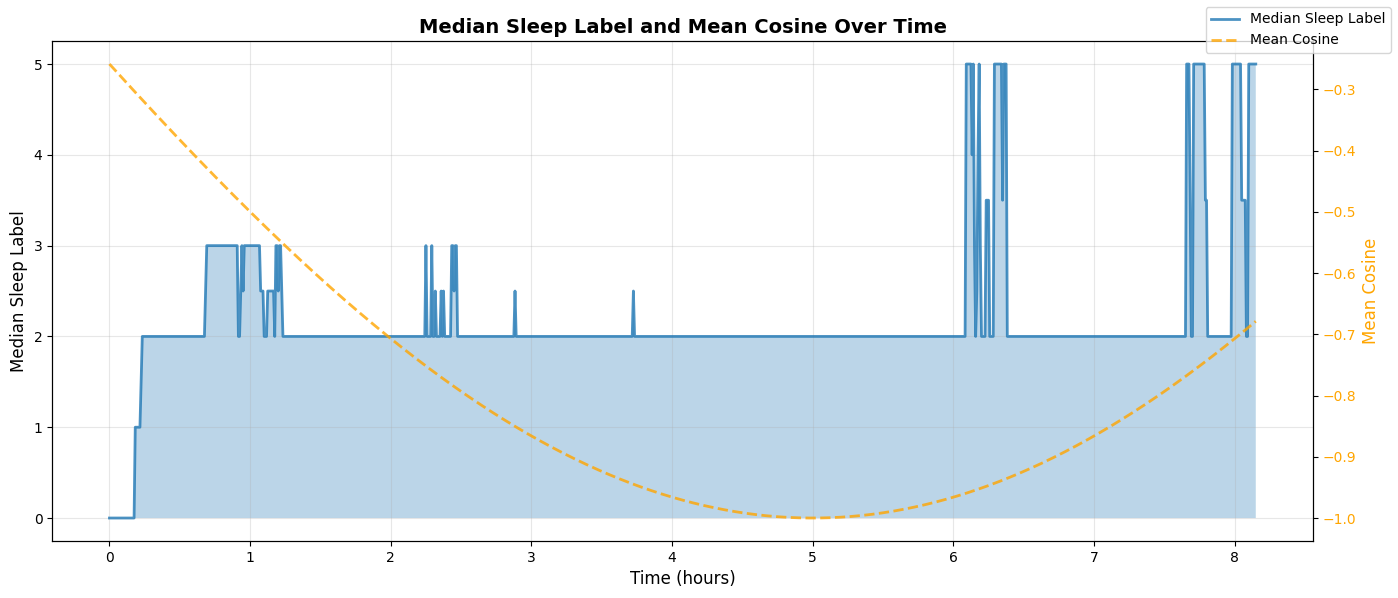

In [ ]:
# Calculate median sleep label for each time period
median_by_time = df_cleaned.groupby('time')['sleep_label'].median().reset_index()
mean_cosine_by_time = df_cleaned.groupby('time')['cosine'].mean().reset_index()

# Create the plot with two y-axes
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(median_by_time['time'], median_by_time['sleep_label'], 
         linewidth=2, alpha=0.8, label='Median Sleep Label')
ax1.fill_between(median_by_time['time'], median_by_time['sleep_label'], 
                 alpha=0.3)
ax1.set_xlabel('Time (hours)', fontsize=12)
ax1.set_ylabel('Median Sleep Label', fontsize=12)
ax1.tick_params(axis='y')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()

ax2.plot(mean_cosine_by_time['time'], mean_cosine_by_time['cosine'], 
         linewidth=2, alpha=0.8, color='orange', label='Mean Cosine', linestyle='--')
ax2.set_ylabel('Mean Cosine', fontsize=12, color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

# Add title and legends
plt.title('Median Sleep Label and Mean Cosine Over Time', fontsize=14, fontweight='bold')
fig.legend(loc='upper right')
plt.tight_layout()
plt.show()

## Methods

### Correlation plot

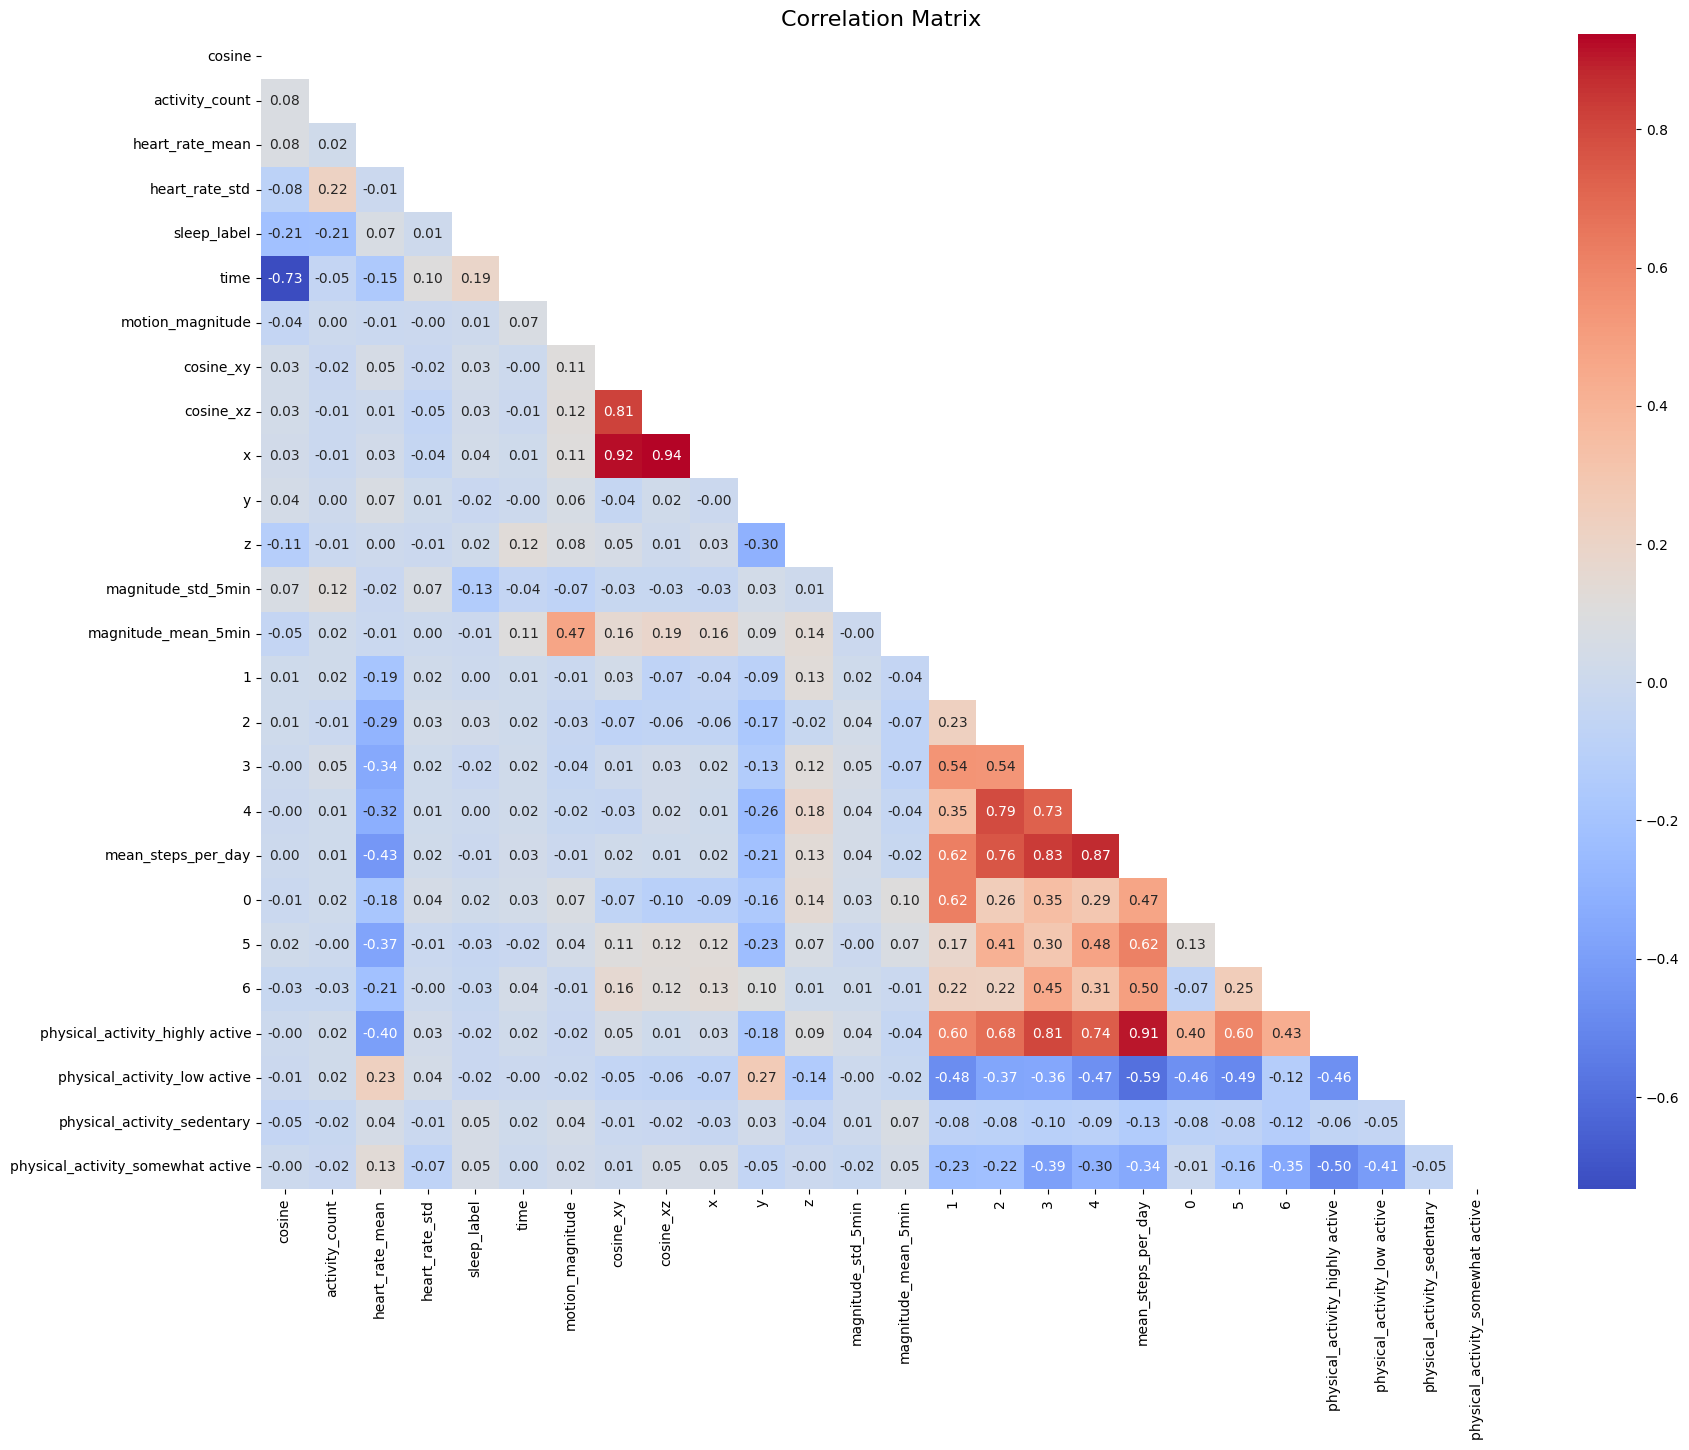

In [111]:
# Correlation Matrix
correlation_matrix = df_cleaned.corr()

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

plt.figure(figsize=(20, 15))  
plt.title('Correlation Matrix', fontsize=16)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar=True, mask=mask)
plt.show()

### Model Training

In [ ]:
# Split features and target variable
#
X = df_cleaned.drop(columns=['sleep_label'])
y = df_cleaned['sleep_label']

In [39]:
# Split the dataset into training and testing sets with stratification
#
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,  
    random_state=42,
    stratify=y)

In [40]:
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [41]:
def evaluate_model(y_test, y_pred):
    """
    Evaluate the model's performance using accuracy, precision, recall, and F1-score.
    Returns:
    - accuracy
    - precision
    - recall
    - f1
    """

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    return accuracy, precision, recall, f1

def run_model(model, X_train, y_train, X_test, y_test):
    """
    Train the model and evaluate its performance.
    Returns:
    - metrics: dictionary containing accuracy, precision, recall, and f1-score
    - y_pred: predicted labels
    - y_pred_prob: predicted probabilities
    """
    metrics = {}
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)
    accuracy, precision, recall, f1 = evaluate_model(y_test, y_pred)

    metrics['accuracy'] = accuracy
    metrics['precision'] = precision
    metrics['recall'] = recall
    metrics['f1'] = f1

    return metrics, y_pred, y_pred_prob

In [42]:
# Define models to evaluate
#
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest 100': RandomForestClassifier(n_estimators=100, random_state=42),
    'Random Forest 200': RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting 100': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting 200': GradientBoostingClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting 500': GradientBoostingClassifier(n_estimators=500, random_state=42),
    'KNN 3': KNeighborsClassifier(n_neighbors=3),
    'KNN 5': KNeighborsClassifier(n_neighbors=5),
    'KNN 7': KNeighborsClassifier(n_neighbors=7),
    'SVM rbf': SVC(kernel='rbf', random_state=42, probability=True),
    'SVM poly': SVC(kernel='poly', random_state=42, probability=True)
}

In [43]:
# Run and evaluate each model
results = []
for model_name, model in models.items():
    metrics, predicted_values, pred_probab = run_model(model, X_train_scaled, y_train, X_test_scaled, y_test)
    
    results.append({'Model Name': model_name, 'Accuracy':metrics['accuracy'],
                    'Precision': metrics['precision'] ,'Recall': metrics['recall'],
                    'F1-Score': metrics['f1'], 'Predicted Values': predicted_values, 
                    'Prediction Probabilities': pred_probab})

In [44]:
results_df = pd.DataFrame(results)
results_df

,Model Name,Accuracy,Precision,Recall,F1-Score,Predicted Values,Prediction Probabilities
0,Logistic Regression,0.540926,0.512864,0.540926,0.489339,"[5.0, 2.0, 5.0, 5.0, 2.0, 2.0, 2.0, 2.0, 2.0, ...","[[0.03655778195878187, 0.1591754151004837, 0.3..."
1,Random Forest 100,0.896165,0.889100,0.896165,0.891321,"[2.0, 2.0, 5.0, 5.0, 2.0, 2.0, 2.0, 2.0, 2.0, ...","[[0.06, 0.34, 0.58, 0.01, 0.0, 0.01], [0.0, 0...."
2,Random Forest 200,0.893358,0.886028,0.893358,0.888322,"[2.0, 2.0, 5.0, 5.0, 2.0, 2.0, 2.0, 2.0, 2.0, ...","[[0.06, 0.3, 0.615, 0.005, 0.0, 0.02], [0.0, 0..."
3,Gradient Boosting 100,0.750935,0.749235,0.750935,0.736030,"[2.0, 2.0, 5.0, 5.0, 2.0, 2.0, 5.0, 2.0, 2.0, ...","[[0.036794183131090924, 0.12559059474489764, 0..."
4,Gradient Boosting 200,0.803789,0.797693,0.803789,0.792356,"[2.0, 2.0, 5.0, 5.0, 2.0, 2.0, 2.0, 2.0, 2.0, ...","[[0.044051474138952246, 0.15195150870232135, 0..."
5,Gradient Boosting 500,0.849860,0.840374,0.849860,0.841225,"[2.0, 2.0, 5.0, 5.0, 2.0, 2.0, 2.0, 2.0, 2.0, ...","[[0.03392998022361307, 0.1586714444145769, 0.7..."
6,KNN 3,0.836763,0.834287,0.836763,0.834848,"[2.0, 2.0, 5.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, ...","[[0.0, 0.3333333333333333, 0.6666666666666666,..."
7,KNN 5,0.830449,0.822357,0.830449,0.825149,"[2.0, 2.0, 5.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, ...","[[0.0, 0.2, 0.8, 0.0, 0.0, 0.0], [0.0, 0.0, 1...."
8,KNN 7,0.811974,0.800523,0.811974,0.803879,"[2.0, 2.0, 5.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, ...","[[0.0, 0.2857142857142857, 0.7142857142857143,..."
9,SVM rbf,0.715856,0.702419,0.715856,0.689034,"[2.0, 2.0, 5.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, ...","[[0.021267027769675678, 0.08391576819373192, 0..."


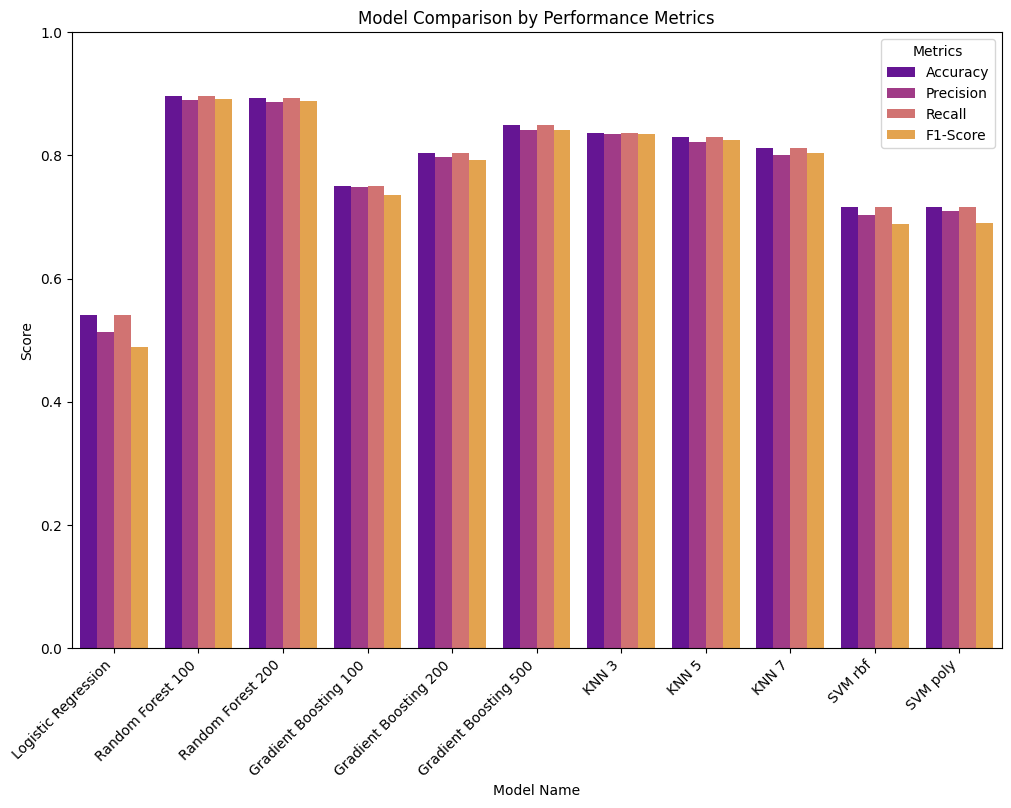

In [45]:
plt.figure(figsize=(12, 8))

df_melted = results_df.iloc[:, :-2].melt(id_vars=['Model Name'], var_name='Metric', value_name='Score')
sns.barplot(x='Model Name', y='Score', hue='Metric', data=df_melted, palette='plasma')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Model Name')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.title('Model Comparison by Performance Metrics')
plt.legend(title='Metrics')
plt.show()

#### Advanced Method Result Analysis

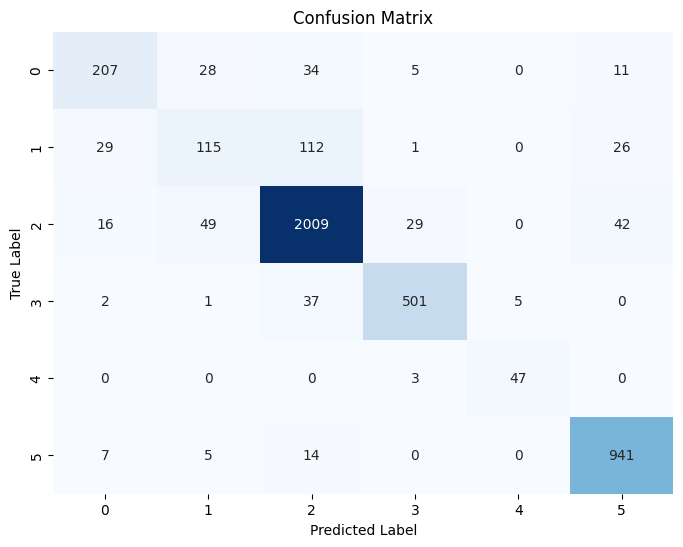

In [48]:
cm = confusion_matrix(y_test, results_df['Predicted Values'][2])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


In [49]:
print(classification_report(y_test, results_df['Predicted Values'][2]))

              precision    recall  f1-score   support

         0.0       0.79      0.73      0.76       285
         1.0       0.58      0.41      0.48       283
         2.0       0.91      0.94      0.92      2145
         3.0       0.93      0.92      0.92       546
         4.0       0.90      0.94      0.92        50
         5.0       0.92      0.97      0.95       967

    accuracy                           0.89      4276
   macro avg       0.84      0.82      0.83      4276
weighted avg       0.89      0.89      0.89      4276



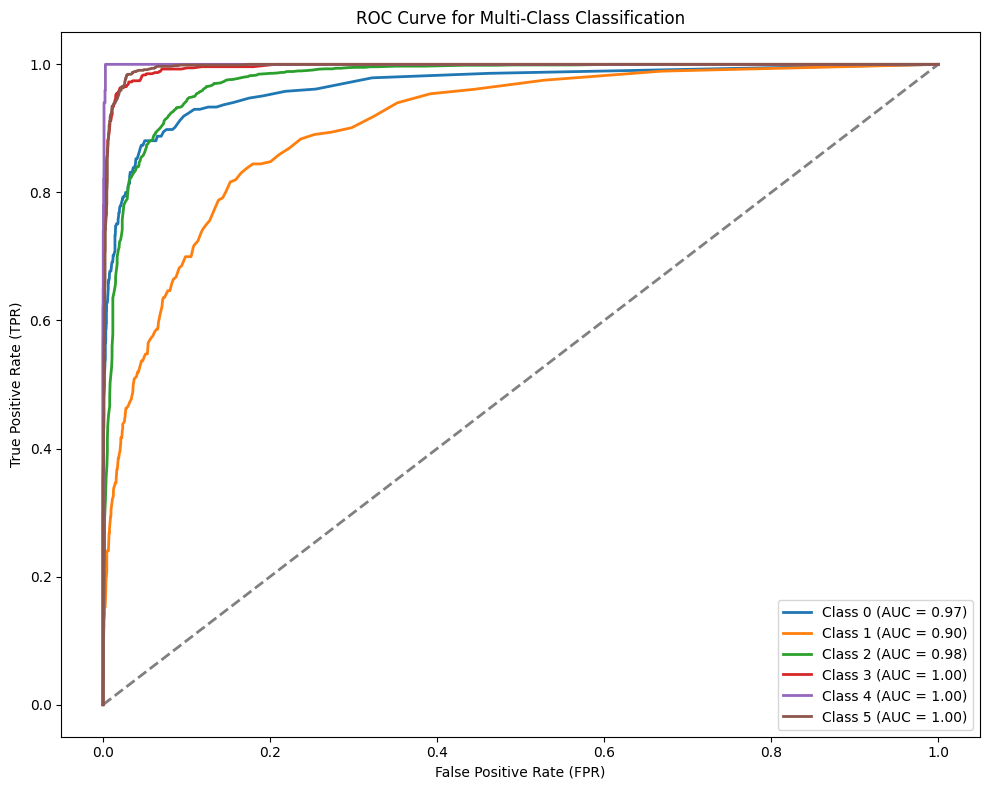

In [ ]:
# Plot ROC AUC
n_classes = results_df['Prediction Probabilities'][2].shape[1]  # Get the number of classes
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3, 4, 5])  # Adjust based on the number of classes

plt.figure(figsize=(10, 8))
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2)

# Loop over all classes
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], results_df['Prediction Probabilities'][2][:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Class {i} (AUC = {roc_auc:.2f})')


# Labels and title
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve for Multi-Class Classification')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


##### Interpretability

In [ ]:
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train_scaled, y_train)

# Get feature importances
importances = model.feature_importances_

# Sort the features by importance
indices = importances.argsort()


In [ ]:
# Create a SHAP explainer for the Random Forest model
explainer = shap.TreeExplainer(model)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test_scaled)

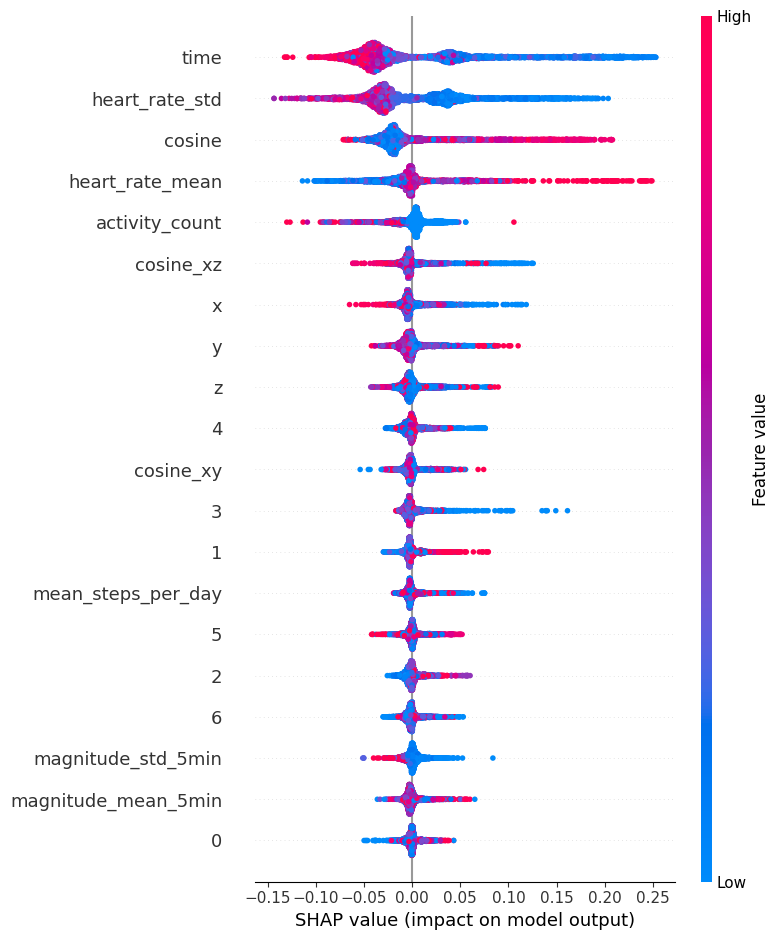

In [54]:
class_3_shap_values = shap_values[:,:,3]

# Create a summary plot for class 3
plt.figure(figsize=(10, 6))
shap.summary_plot(class_3_shap_values, X_test_scaled, feature_names=X.columns)
plt.show()

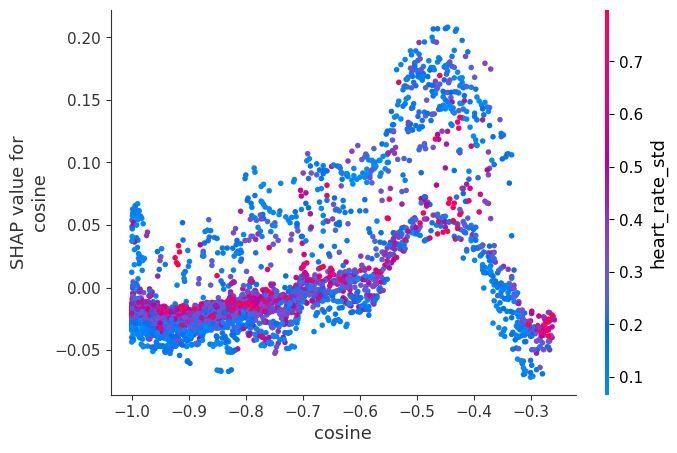

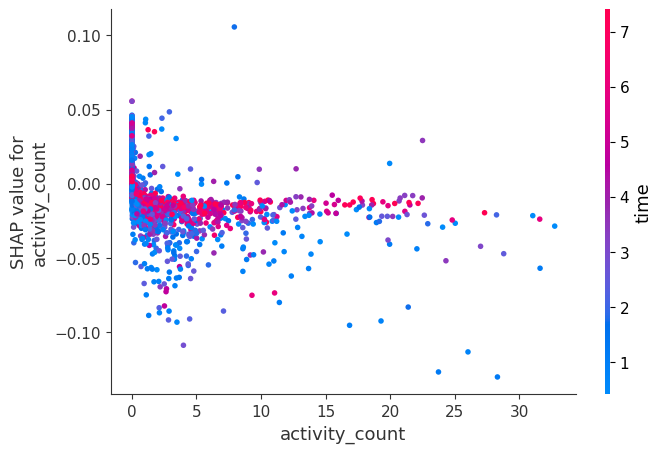

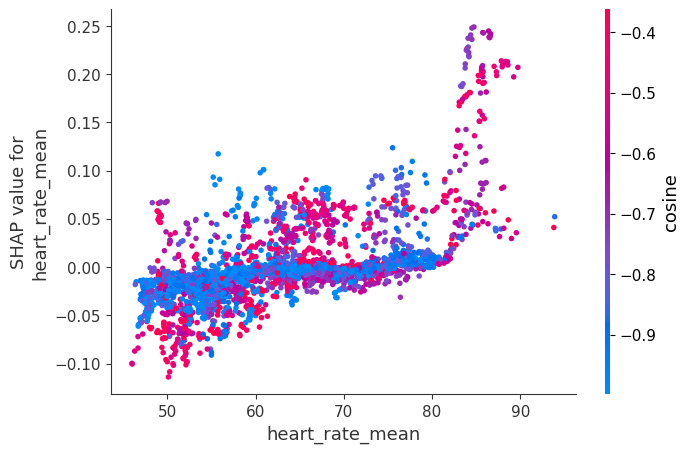

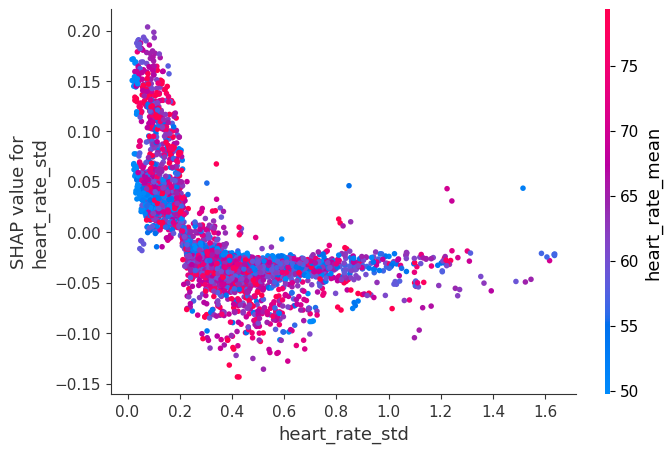

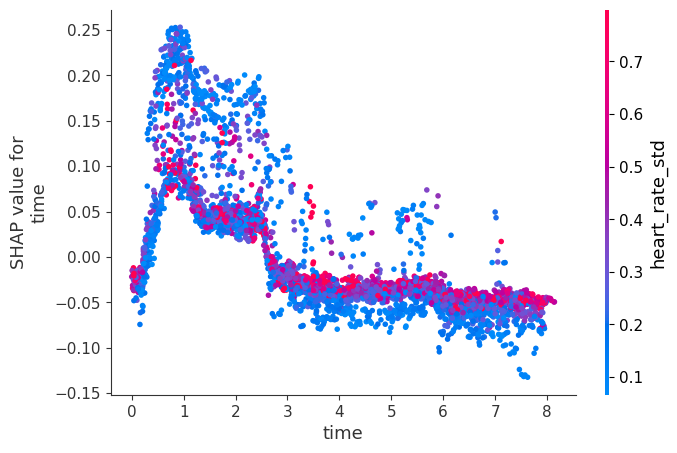

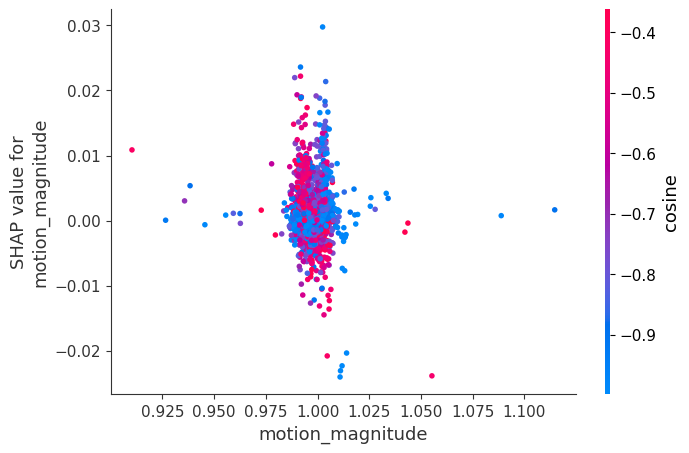

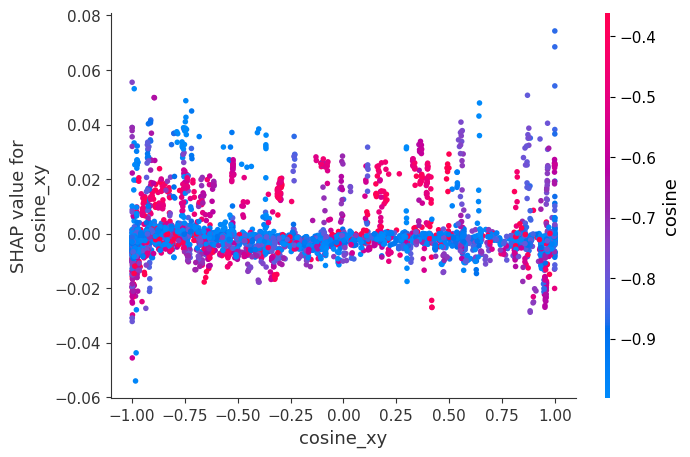

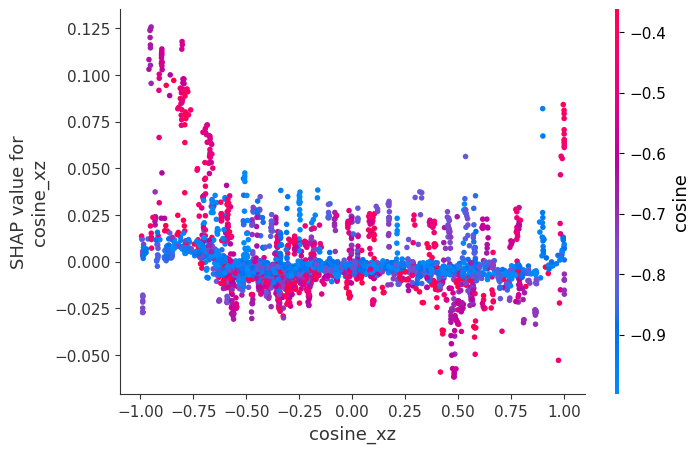

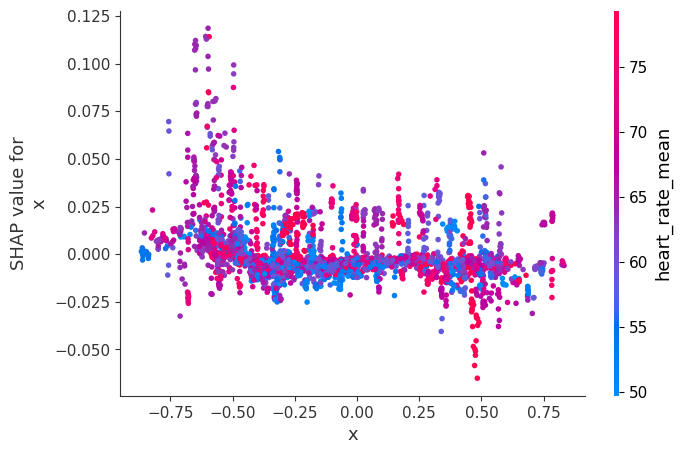

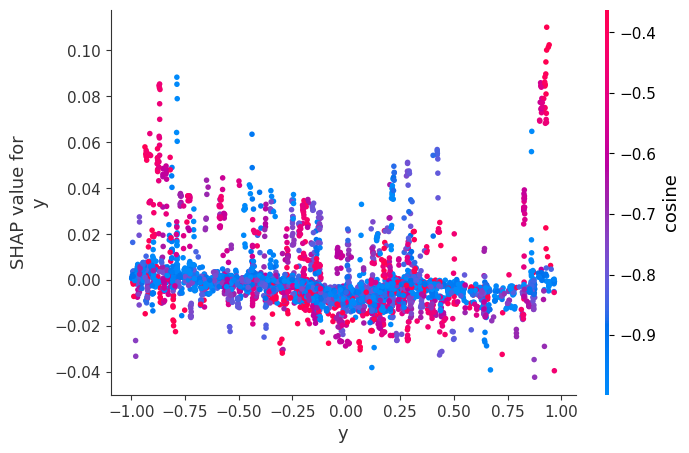

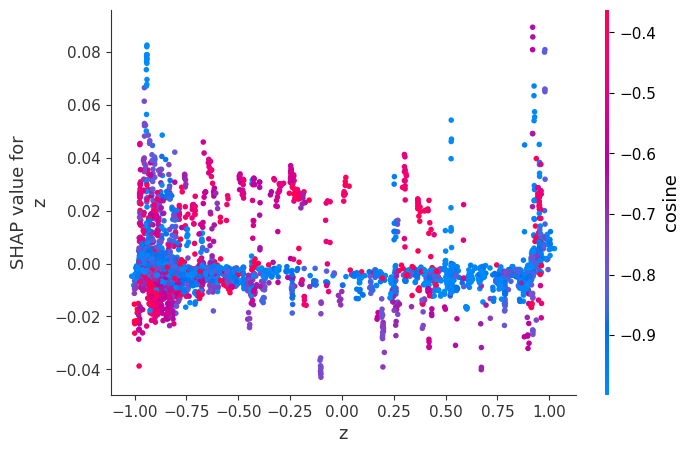

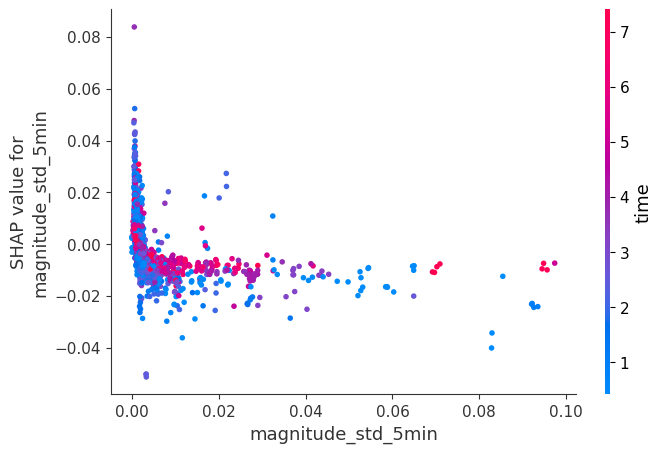

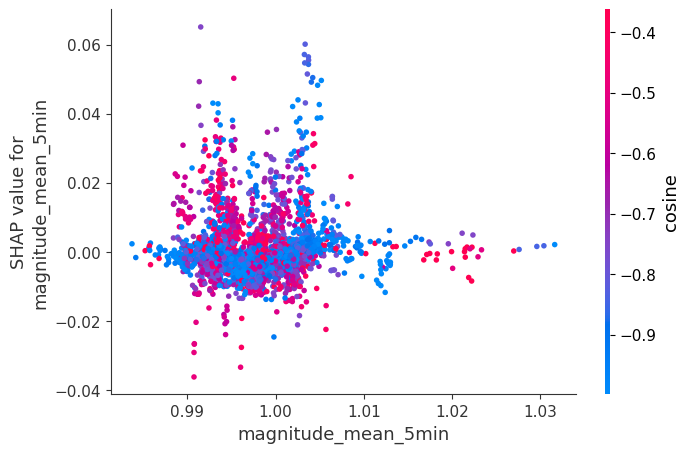

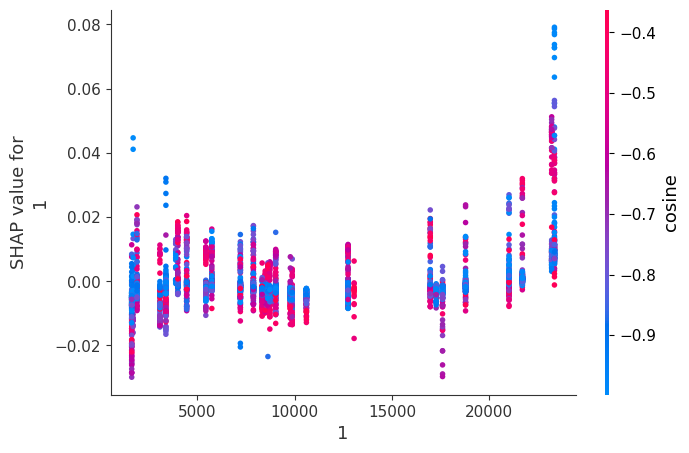

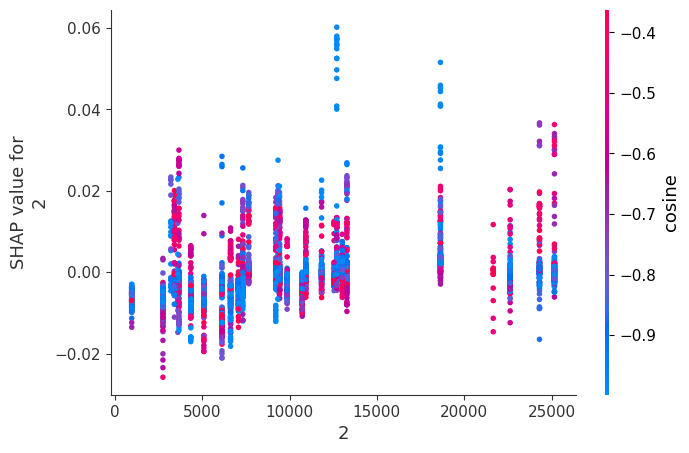

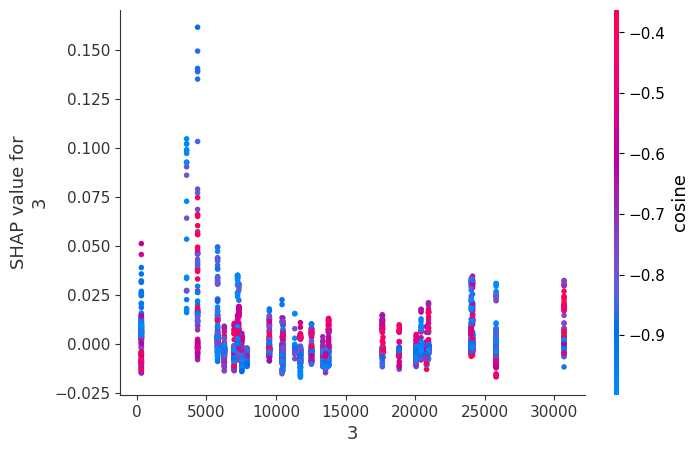

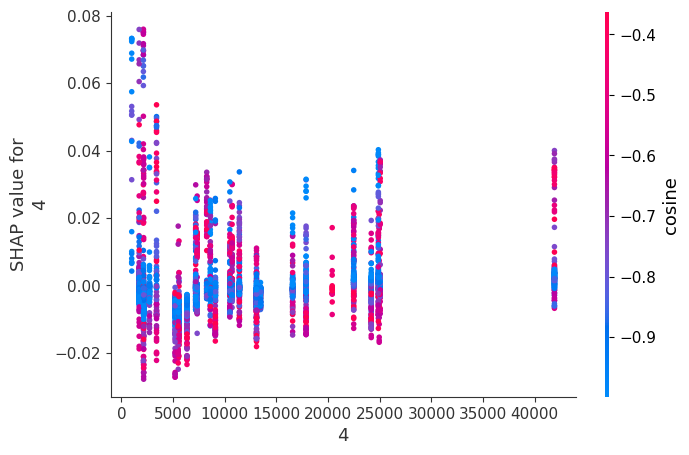

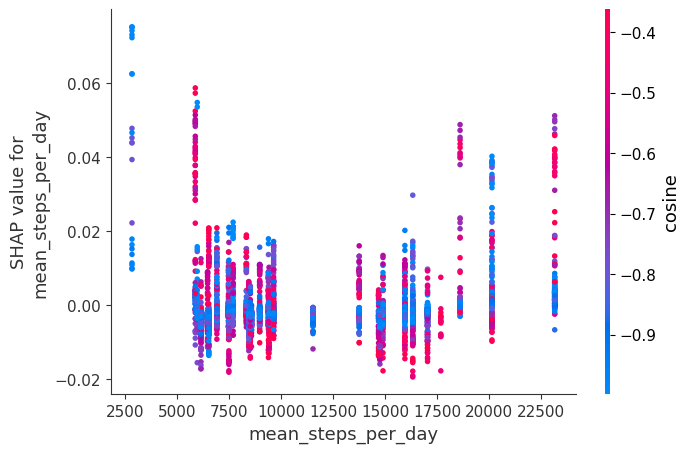

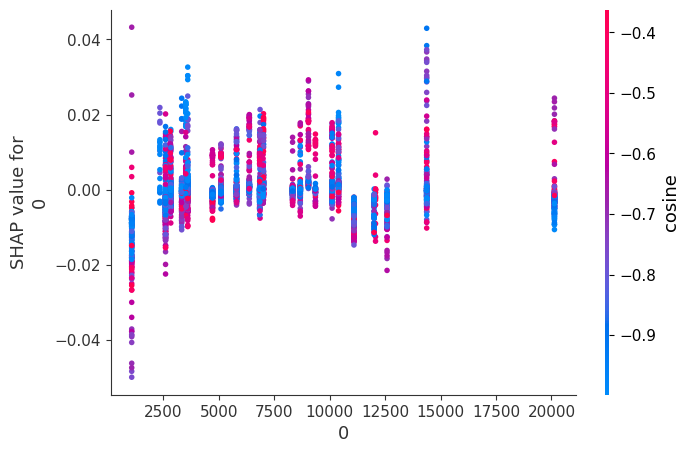

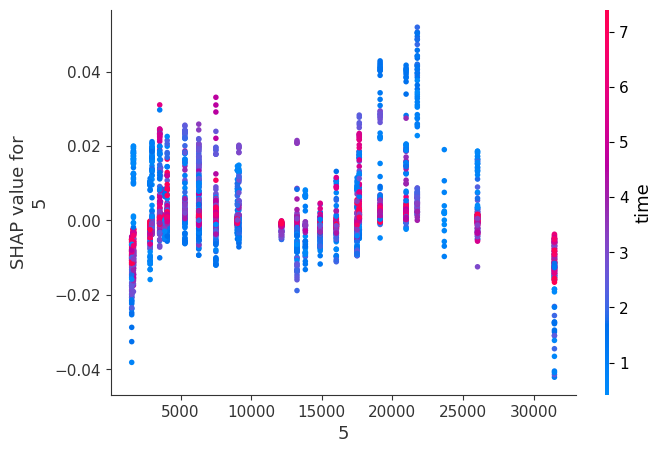

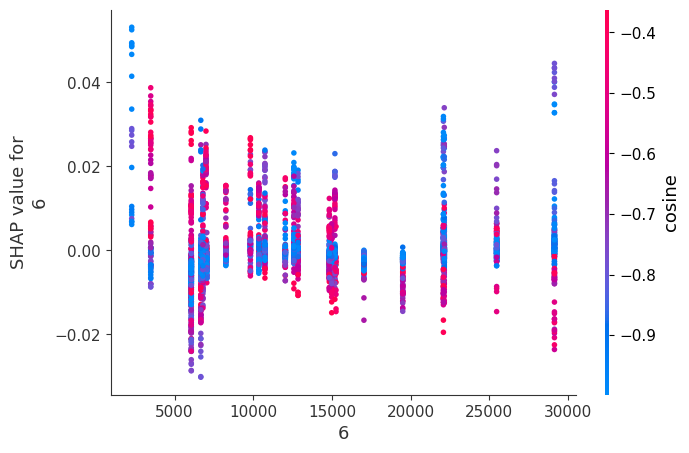

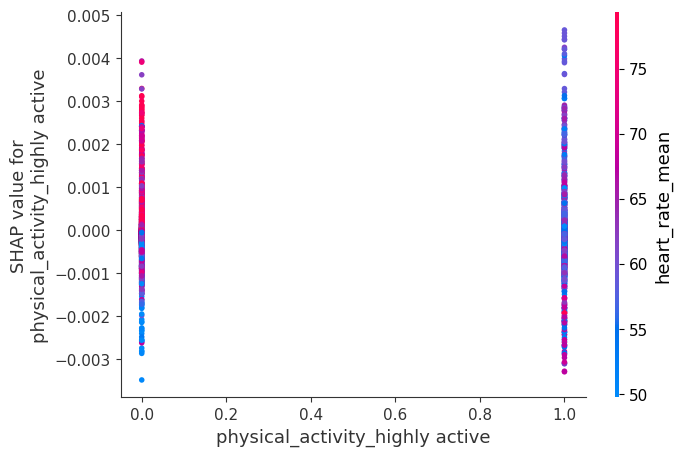

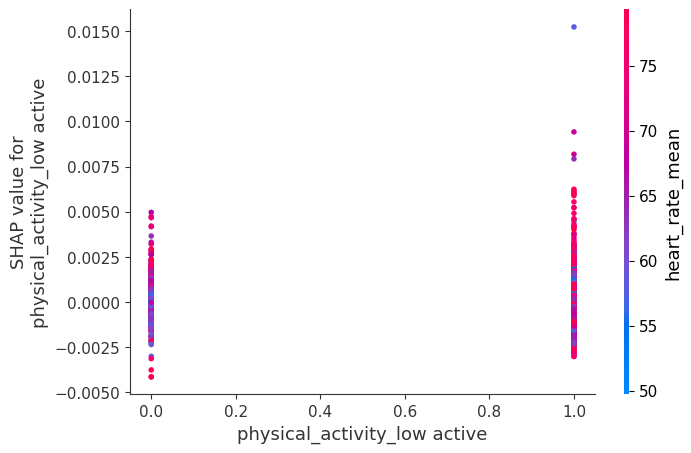

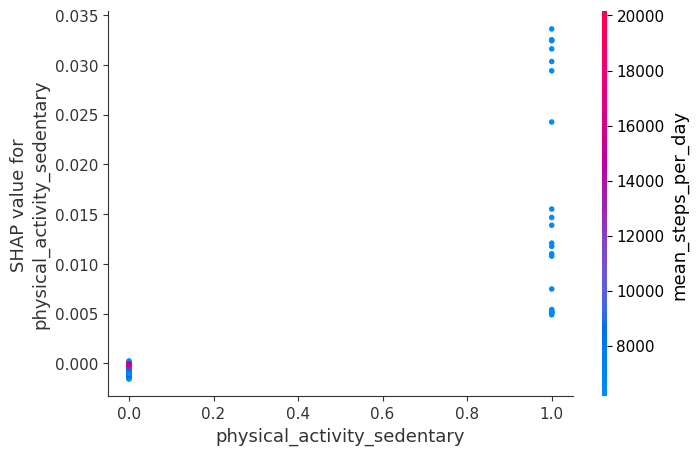

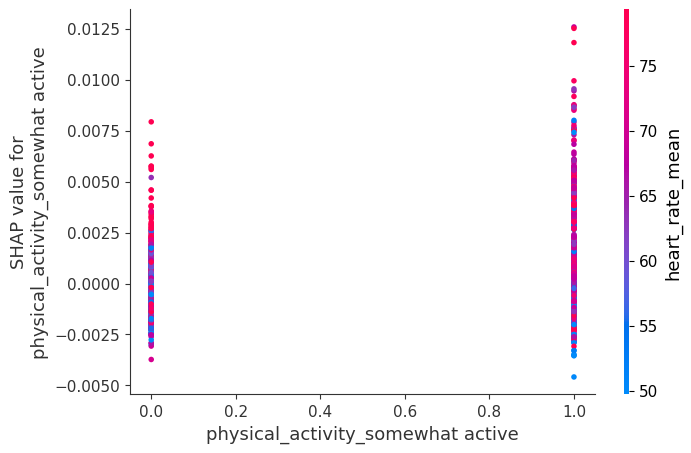

In [55]:
for feature in X.columns:
    shap.dependence_plot(feature, class_3_shap_values, X_test)